# Notebook 07 — Commercial Banks Sector Recurrent Pretraining

This is one predefined research run of a **Commercial Banks sector foundation RecurrentPPO**. It is not a transfer-learning result, Cold Start model, symbol-specific model, or production trading model. TRAIN alone updates weights; VALIDATION is inference-only; TEST remains sealed.

In [1]:
from pathlib import Path
import hashlib, json, sys, tempfile
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
assert Path(sys.executable).resolve() == (PROJECT_ROOT / '.venv/bin/python').resolve()
print('Project interpreter:', sys.executable)

Project interpreter: /Users/m.abdulbasit/Downloads/virtual-trader/.venv/bin/python


In [2]:
from data_pipeline.src.config import MODEL_REGISTRY_PATH, MODELS_DATA_DIR, SAVED_MODELS_DIR
from reinforcement_learning.recurrent_data_contract import load_recurrent_partition
from reinforcement_learning.training.sector_recurrent_config import SectorRecurrentPPOConfig
from reinforcement_learning.training.sector_recurrent_trainer import (
    COMMERCIAL_BANKS_MANIFEST_PATH, load_sector_training_universe, train_sector_recurrent_ppo,
)
from reinforcement_learning.evaluation.sector_recurrent_evaluator import evaluate_sector_recurrent_on_validation
from reinforcement_learning.model_management.sector_recurrent_persistence import verify_temporary_sector_round_trip
from reinforcement_learning.sector_universe import build_leave_one_out_sector_manifest

def tree_hashes(root):
    root = Path(root)
    return {str(p.relative_to(root)): hashlib.sha256(p.read_bytes()).hexdigest() for p in root.rglob('*') if p.is_file()}

registry_before = MODEL_REGISTRY_PATH.read_bytes()
models_before = {str(p): tree_hashes(p) for p in (SAVED_MODELS_DIR, MODELS_DATA_DIR)}
partition_trace = []
def train_only_loader(symbol, partition, **kwargs):
    assert partition == 'train'
    partition_trace.append((symbol, partition))
    return load_recurrent_partition(symbol, partition, **kwargs)
def validation_only_loader(symbol, partition, **kwargs):
    assert partition == 'validation'
    partition_trace.append((symbol, partition))
    return load_recurrent_partition(symbol, partition, **kwargs)

## Immutable universe and methodology

The scheduler uses deterministic shuffled cycles. Episode selection is equal, but actual timesteps can remain unequal because symbols retain full natural episode lengths. Every symbol transition is a Gymnasium termination/reset, clearing portfolio state and causing RecurrentPPO to set `episode_start=True`.

In [3]:
manifest = json.loads(COMMERCIAL_BANKS_MANIFEST_PATH.read_text())
universe = load_sector_training_universe(partition_loader=train_only_loader)
print('Universe hash:', universe.universe_hash)
print('Constituents:', ', '.join(universe.symbols))
display(pd.DataFrame({'symbol': universe.symbols, 'train_rows': [universe.train_rows[s] for s in universe.symbols]}))
assert len(universe.symbols) == 19 and universe.total_train_rows == 31157
assert universe.observation_shape == (17,)
partition_trace.clear()  # trace only the actual training/evaluation actions below

Universe hash: 589485c8adfe6170a6c2391687202ac3a287de9eb30737a2cb1f57a34f111e5b
Constituents: ABL, AKBL, BAFL, BAHL, BIPL, BML, BOK, BOP, FABL, HBL, HMB, JSBL, MCB, MEBL, NBP, SBL, SCBPL, SNBL, UBL


,symbol,train_rows
0,ABL,1660
1,AKBL,1703
2,BAFL,1703
3,BAHL,1704
4,BIPL,1649
5,BML,1703
6,BOK,1484
7,BOP,1704
8,FABL,1701
9,HBL,1704


In [4]:
SEED = 42
DEVICE = 'cpu'
SMOKE_TIMESTEPS = 2_048  # executed separately before this notebook
RESEARCH_TIMESTEPS = 50_000  # predefined to exceed one 31,138-step full cycle
config = SectorRecurrentPPOConfig.from_manifest(
    manifest, seed=SEED, total_timesteps=RESEARCH_TIMESTEPS, device=DEVICE
)
display(pd.DataFrame([config.to_dict()['ppo']]).T.rename(columns={0: 'value'}))

,value
config_version,recurrent_ppo_single_symbol_v1
algorithm,RecurrentPPO
policy,MlpLstmPolicy
learning_rate,0.0003
n_steps,512
batch_size,64
n_epochs,10
gamma,0.99
gae_lambda,0.95
clip_range,0.2


In [5]:
training = train_sector_recurrent_ppo(
    config=config, partition_loader=train_only_loader
)
assert training.succeeded, training.error
print(f'Completed {training.actual_timesteps:,} total sector timesteps in {training.duration_seconds:.2f}s')
print(f'Throughput: {training.actual_timesteps / training.duration_seconds:.2f} steps/s')
print('Sampling sequence digest:', training.sampling_sequence_digest)
print('Sampling sequence:', training.sampling_sequence)

Completed 50,176 total sector timesteps in 111.81s
Throughput: 448.76 steps/s
Sampling sequence digest: 609eecfc4ba44451e986541ed3f1cb3a311e9dcf09f71c9beebeace0b1d6914e
Sampling sequence: ('BAFL', 'FABL', 'HMB', 'NBP', 'ABL', 'SBL', 'UBL', 'MEBL', 'AKBL', 'BAHL', 'BML', 'BOP', 'HBL', 'BOK', 'BIPL', 'MCB', 'SCBPL', 'SNBL', 'JSBL', 'AKBL', 'MEBL', 'BAFL', 'SCBPL', 'BOK', 'UBL', 'JSBL', 'BOP', 'FABL', 'NBP', 'ABL', 'HBL')


In [6]:
exposure = pd.DataFrame({
    'symbol': training.constituent_symbols,
    'episodes_started': [training.episode_counts_started[s] for s in training.constituent_symbols],
    'episodes_completed': [training.episode_counts_completed[s] for s in training.constituent_symbols],
    'timesteps': [training.timesteps_by_symbol[s] for s in training.constituent_symbols],
    'contribution_percent': [training.timestep_contribution_percentages[s] for s in training.constituent_symbols],
})
display(exposure)
print('Never sampled:', training.constituents_never_sampled or 'None')
print('Termination reasons:', dict(training.termination_reasons))
print('Warnings:', training.warnings or 'None')
display(pd.DataFrame([training.training_diagnostics.to_dict()]))

,symbol,episodes_started,episodes_completed,timesteps,contribution_percent
0,ABL,2,2,3318,6.612723
1,AKBL,2,2,3404,6.784120
2,BAFL,2,2,3404,6.784120
3,BAHL,1,1,1703,3.394053
4,BIPL,1,1,1648,3.284439
5,BML,1,1,1702,3.392060
6,BOK,2,2,2966,5.911193
7,BOP,2,2,3406,6.788106
8,FABL,2,2,3400,6.776148
9,HBL,2,1,2557,5.096062


Never sampled: None
Termination reasons: {'natural_train_partition_end': 30}
Warnings: ('Equal episode selection produced unequal timestep exposure because full episode lengths differ.',)


,timesteps,updates,approximate_kl,clip_fraction,entropy_loss,explained_variance,policy_gradient_loss,value_loss,learning_rate
0,50176,980,0.008941,0.097656,-0.502825,0.630388,-0.019343,0.000581,0.0003


## Independent VALIDATION episodes

The shared model is evaluated separately on every bank. Each begins with the same initial capital, `lstm_state=None`, and `episode_start=True`. Portfolios are never chained or compounded across symbols.

In [7]:
validation = evaluate_sector_recurrent_on_validation(
    training, partition_loader=validation_only_loader, deterministic_seed=SEED, random_seed=SEED
)
assert validation.model_parameters_unchanged and not validation.test_evaluated
rows = []
strategy_rows = []
for item in validation.symbol_results:
    rows.append({
        'symbol': item.symbol, 'rows': item.validation_rows,
        'ppo_return': item.ppo.metrics['total_return'],
        'buy_hold_return': item.buy_and_hold.metrics['total_return'],
        'ppo_sharpe': item.ppo.metrics['sharpe_ratio'],
        'ppo_sortino': item.ppo.metrics['sortino_ratio'],
        'ppo_volatility': item.ppo.metrics['annualized_volatility'],
        'ppo_max_drawdown': item.ppo.metrics['maximum_drawdown'],
        'trades': item.ppo.metrics['number_of_trades'],
        'transaction_costs': item.ppo.metrics['total_transaction_costs'],
        'exposure_percent': item.ppo.metrics['exposure_percentage'],
        'final_value': item.ppo.metrics['final_portfolio_value'],
    })
    for strategy_name, strategy in (
        ('Sector RecurrentPPO', item.ppo), ('Buy and Hold', item.buy_and_hold),
        ('Always Hold', item.always_hold), ('Random', item.random),
    ):
        metric = strategy.metrics
        strategy_rows.append({
            'symbol': item.symbol, 'strategy': strategy_name,
            'final_portfolio_value': metric['final_portfolio_value'],
            'total_return': metric['total_return'],
            'annualized_return': metric['annualized_return'],
            'annualized_volatility': metric['annualized_volatility'],
            'sharpe_ratio': metric['sharpe_ratio'], 'sortino_ratio': metric['sortino_ratio'],
            'maximum_drawdown': metric['maximum_drawdown'],
            'number_of_trades': metric['number_of_trades'],
            'total_transaction_costs': metric['total_transaction_costs'],
            'exposure_percentage': metric['exposure_percentage'],
        })
validation_table = pd.DataFrame(rows)
display(validation_table)
display(pd.DataFrame(strategy_rows))

,symbol,rows,ppo_return,buy_hold_return,ppo_sharpe,ppo_sortino,ppo_volatility,ppo_max_drawdown,trades,transaction_costs,exposure_percent,final_value
0,ABL,355,-0.073555,0.996839,-0.473485,-0.627305,0.103513,0.130414,16,24413.986410,8.192090,9.264453e+05
1,AKBL,365,0.099749,1.608671,0.598894,1.145223,0.122133,0.116975,8,12459.610946,12.362637,1.099749e+06
2,BAFL,365,0.043501,0.836262,0.815738,1.714395,0.036967,0.026914,8,12488.195141,1.648352,1.043501e+06
3,BAHL,365,0.155876,1.546862,1.583713,3.023928,0.064648,0.040047,6,10085.883284,5.219780,1.155876e+06
4,BIPL,353,-0.060634,0.406248,-0.986984,-1.070830,0.044354,0.065028,8,11852.924191,1.988636,9.393660e+05
5,BML,364,0.023347,1.196703,0.261119,0.488723,0.070721,0.052333,4,5945.597394,1.928375,1.023347e+06
6,BOK,318,0.235203,0.268889,0.626880,0.931299,0.389666,0.265992,12,22674.444661,32.176656,1.235203e+06
7,BOP,365,0.480603,2.072902,1.345572,2.043810,0.220224,0.180941,28,57465.207906,25.549451,1.480603e+06
8,FABL,364,-0.053678,1.091766,-0.501980,-0.565670,0.071128,0.093375,10,14874.338062,2.479339,9.463220e+05
9,HBL,365,0.012788,0.639939,0.141244,0.220771,0.092119,0.061419,14,20659.872271,7.142857,1.012788e+06


,symbol,strategy,final_portfolio_value,total_return,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,maximum_drawdown,number_of_trades,total_transaction_costs,exposure_percentage
0,ABL,Sector RecurrentPPO,9.264453e+05,-0.073555,-0.052934,0.103513,-0.473485,-0.627305,0.130414,16,24413.986410,8.192090
1,ABL,Buy and Hold,1.996839e+06,0.996839,0.636076,0.294144,1.820807,3.018566,0.157369,1,1498.219240,100.000000
2,ABL,Always Hold,1.000000e+06,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0,0.000000,0.000000
3,ABL,Random,9.374905e+05,-0.062510,-0.044910,0.237642,-0.074943,-0.108942,0.178654,123,183111.540190,49.717514
4,AKBL,Sector RecurrentPPO,1.099749e+06,0.099749,0.068041,0.122133,0.598894,1.145223,0.116975,8,12459.610946,12.362637
...,...,...,...,...,...,...,...,...,...,...,...,...
71,SNBL,Random,8.388558e+05,-0.161144,-0.121112,0.235968,-0.430104,-0.638599,0.277645,114,156475.166444,51.603499
72,UBL,Sector RecurrentPPO,1.016837e+06,0.016837,0.011627,0.008547,1.356726,NaN,0.000000,4,6048.338357,0.549451
73,UBL,Buy and Hold,2.801914e+06,1.801914,1.040687,0.266754,2.810018,4.974437,0.110113,1,1498.135212,100.000000
74,UBL,Always Hold,1.000000e+06,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0,0.000000,0.000000


,value
symbols_evaluated,19
evaluation_failures,0
failed_symbols,[]
aggregation_interpretation,statistics_of_independent_equal_capital_episodes
symbols_beating_buy_and_hold_return,1
...,...
random_exposure_percentage.median,51.515152
random_exposure_percentage.minimum,43.573668
random_exposure_percentage.maximum,54.985755
random_exposure_percentage.q25,48.485131


Collapse diagnostics:
{
  "action_counts": {
    "Hold": 372,
    "Buy": 266,
    "Sell": 6014
  },
  "action_percentages": {
    "Hold": 5.592303066746843,
    "Buy": 3.998797354179194,
    "Sell": 90.40889957907396
  },
  "zero_trade_symbol_count": 1,
  "zero_trade_symbols": [
    "MEBL"
  ],
  "median_exposure_percentage": 4.1208791208791204,
  "identical_action_pattern_groups": [],
  "warnings": [],
  "obvious_policy_collapse_flag": false
}


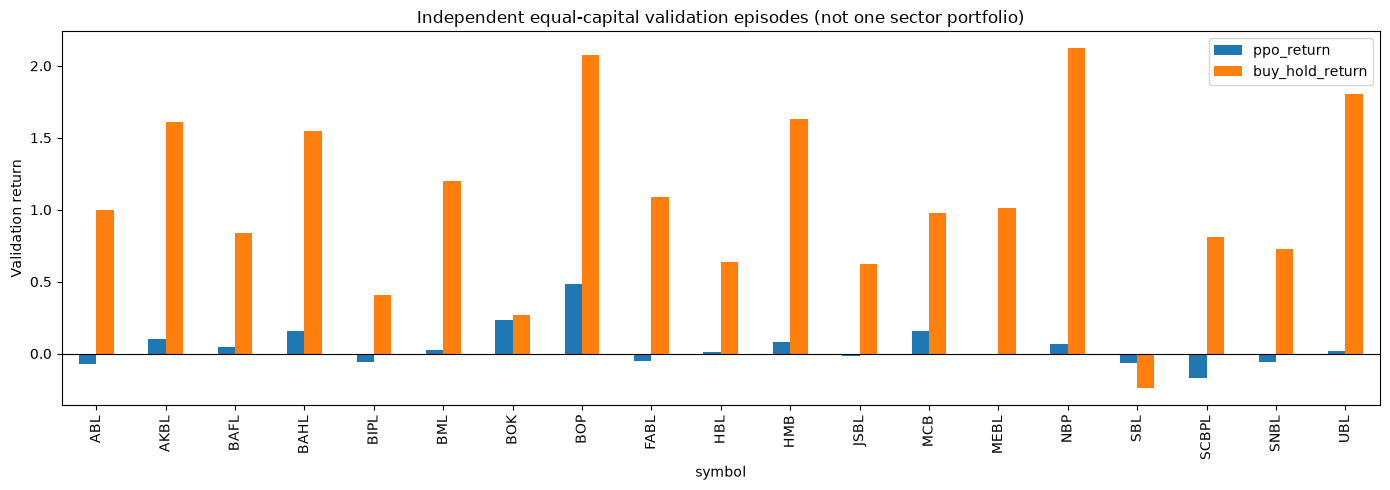

In [8]:
display(pd.json_normalize(validation.aggregate_metrics, sep='.').T.rename(columns={0: 'value'}))
print('Collapse diagnostics:')
print(json.dumps(validation.collapse_diagnostics, indent=2))
ax = validation_table.set_index('symbol')[['ppo_return', 'buy_hold_return']].plot.bar(figsize=(14, 5))
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Validation return')
ax.set_title('Independent equal-capital validation episodes (not one sector portfolio)')
plt.tight_layout(); plt.show()

## Leave-one-out foundation and temporary round trip

A transfer claim must use a separately trained target-excluded universe. The general 6E model includes all banks and cannot support such a claim.

In [9]:
loo = build_leave_one_out_sector_manifest(
    'MCB', standard_manifest_path=COMMERCIAL_BANKS_MANIFEST_PATH,
    current_verified_path=COMMERCIAL_BANKS_MANIFEST_PATH.parent.parent / 'current_verified_symbols.csv',
)
assert 'MCB' not in loo['experiment_mode']['pretraining_constituent_symbols']
assert 'MCB' not in loo['normalization']['normalization_contributor_symbols']
print('MCB leave-one-out universe hash:', loo['universe_hash'])
print('Target excluded:', loo['experiment_mode']['target_excluded_from_pretraining'])

MCB leave-one-out universe hash: 0e90c86759b3ac5e4fa0d3cf8c4edac802ffb158d2720311b525e5b92f8e60c3
Target excluded: True


In [10]:
with tempfile.TemporaryDirectory(prefix='vt_sector_6e_') as temporary_name:
    temporary_root = Path(temporary_name) / 'bundle'
    persisted = verify_temporary_sector_round_trip(
        training, validation, temporary_root=temporary_root
    )
    round_trip = {
        'deterministic_action_match': persisted.deterministic_action_match,
        'recurrent_state_match': persisted.recurrent_state_match,
        'metadata_integrity_verified': persisted.metadata_integrity_verified,
        'registry_touched': persisted.registry_touched,
        'model_sha256': persisted.model_sha256,
    }
assert not Path(temporary_name).exists()
print(round_trip)
assert MODEL_REGISTRY_PATH.read_bytes() == registry_before
assert {str(p): tree_hashes(p) for p in (SAVED_MODELS_DIR, MODELS_DATA_DIR)} == models_before

{'deterministic_action_match': True, 'recurrent_state_match': True, 'metadata_integrity_verified': True, 'registry_touched': False, 'model_sha256': 'c76e7a7406799beaab19c9867bbf653632e506497a0adabdd255f7339f4a946a'}


In [11]:
assert [p for _, p in partition_trace[:19]] == ['train'] * 19
assert [p for _, p in partition_trace[19:]] == ['validation'] * 19
summary = {
    'trainer_version': training.trainer_version,
    'universe_hash': training.sector_universe_hash,
    'requested_timesteps': training.requested_timesteps,
    'actual_timesteps': training.actual_timesteps,
    'duration_seconds': training.duration_seconds,
    'timesteps_per_second': training.actual_timesteps / training.duration_seconds,
    'sampling_sequence': list(training.sampling_sequence),
    'sampling_sequence_digest': training.sampling_sequence_digest,
    'episodes_started': dict(training.episode_counts_started),
    'episodes_completed': dict(training.episode_counts_completed),
    'timesteps_by_symbol': dict(training.timesteps_by_symbol),
    'timestep_contribution_percentages': dict(training.timestep_contribution_percentages),
    'never_sampled': list(training.constituents_never_sampled),
    'termination_reasons': dict(training.termination_reasons),
    'diagnostics': training.training_diagnostics.to_dict(),
    'aggregate_metrics': dict(validation.aggregate_metrics),
    'collapse_diagnostics': dict(validation.collapse_diagnostics),
    'per_symbol_strategy_metrics': strategy_rows,
    'validation_failures': dict(validation.failures),
    'round_trip': round_trip,
    'test_evaluated': validation.test_evaluated,
    'registry_unchanged': MODEL_REGISTRY_PATH.read_bytes() == registry_before,
    'production_models_unchanged': {str(p): tree_hashes(p) for p in (SAVED_MODELS_DIR, MODELS_DATA_DIR)} == models_before,
}
print('RESULT_JSON=' + json.dumps(summary, sort_keys=True))
print('FINAL TEST SET: SEALED AND UNTOUCHED')

RESULT_JSON={"actual_timesteps": 50176, "aggregate_metrics": {"aggregation_interpretation": "statistics_of_independent_equal_capital_episodes", "always_hold_annualized_return": {"maximum": 0.0, "mean": 0.0, "median": 0.0, "minimum": 0.0, "q25": 0.0, "q75": 0.0}, "always_hold_annualized_volatility": {"maximum": 0.0, "mean": 0.0, "median": 0.0, "minimum": 0.0, "q25": 0.0, "q75": 0.0}, "always_hold_exposure_percentage": {"maximum": 0.0, "mean": 0.0, "median": 0.0, "minimum": 0.0, "q25": 0.0, "q75": 0.0}, "always_hold_maximum_drawdown": {"maximum": 0.0, "mean": 0.0, "median": 0.0, "minimum": 0.0, "q25": 0.0, "q75": 0.0}, "always_hold_number_of_trades": {"maximum": 0.0, "mean": 0.0, "median": 0.0, "minimum": 0.0, "q25": 0.0, "q75": 0.0}, "always_hold_sharpe_ratio": {"maximum": null, "mean": null, "median": null, "minimum": null, "q25": null, "q75": null}, "always_hold_sortino_ratio": {"maximum": null, "mean": null, "median": null, "minimum": null, "q25": null, "q75": null}, "always_hold_tot

## Interpretation boundary

This notebook establishes whether one recurrent policy can be trained across multiple current-sector symbols with strict reset and partition controls. A favorable validation result does **not** prove transfer learning. Transfer benefit requires future target-excluded pretraining, target-only fine-tuning, matched effective exposure/compute, multiple seeds, and predeclared evaluation.

**Post-run policy-collapse interpretation:** the preserved run produced 90.41% Sell actions, median exposure of 4.12%, and one zero-trade symbol. The collapse guard was conservatively hardened after the run to flag action dominance at 90% and median exposure at 5%; therefore this result is classified as a possible sell-dominant/mostly-cash collapse. No retraining or configuration change followed this observation.